In [11]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df["job_skills"]=df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


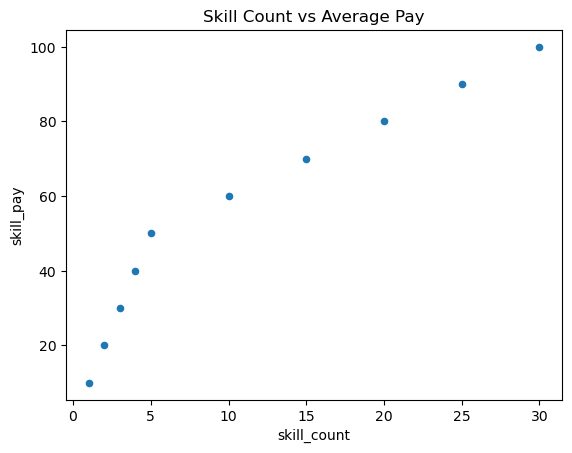

In [12]:
# Sample Data for Visualization

data = {
    'job_skills': ['python', 'sql', 'java', 'c++', 'c#', 'javascript', 'html', 'css', 'php', 'ruby'],
    'skill_count': [30, 25, 20, 15, 10, 5, 4, 3, 2, 1],
    'skill_pay': [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]
}

example_df = pd.DataFrame(data)

example_df.plot(kind='scatter', x='skill_count', y='skill_pay')
plt.title("Skill Count vs Average Pay")
plt.show()

In [13]:
df_DA = df[df['job_title_short'] == 'Data Analyst']
df_explode= df_DA.explode('job_skills')
df_explode

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,power bi,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785717,Data Analyst,Data & Analytics Architect (w/m/x),"Erfurt, Jerman",melalui LinkedIn,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,NTT DATA DACH,azure,"{'cloud': ['aws', 'azure']}"
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sas,"{'analyst_tools': ['sas', 'excel'], 'programmi..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sas,"{'analyst_tools': ['sas', 'excel'], 'programmi..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sql,"{'analyst_tools': ['sas', 'excel'], 'programmi..."


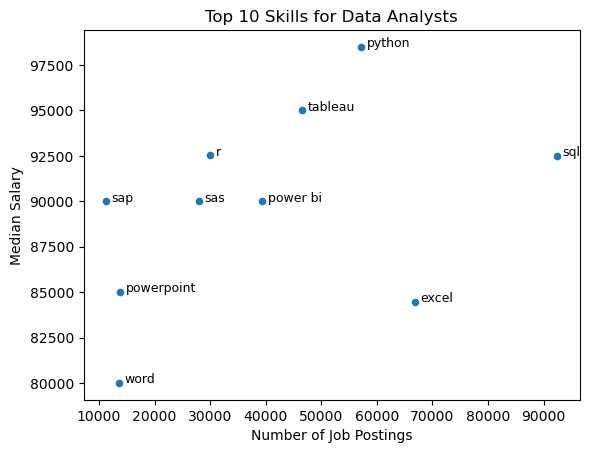

In [14]:
skills_stat= df_explode.groupby('job_skills').agg(
    count=('job_skills', 'count'),
    median_pay=('salary_year_avg', 'median')
)

skills_stat_1= skills_stat.sort_values(by='count', ascending=False).head(10).copy()
skills_stat_1.plot(kind='scatter', x='count', y='median_pay')
plt.title("Top 10 Skills for Data Analysts")
plt.xlabel("Number of Job Postings")
plt.ylabel("Median Salary")

for skill in skills_stat_1.index:
    x = skills_stat_1.loc[skill, 'count']
    y = skills_stat_1.loc[skill, 'median_pay']
    plt.text(x+1000, y, skill, fontsize=9)
plt.show()

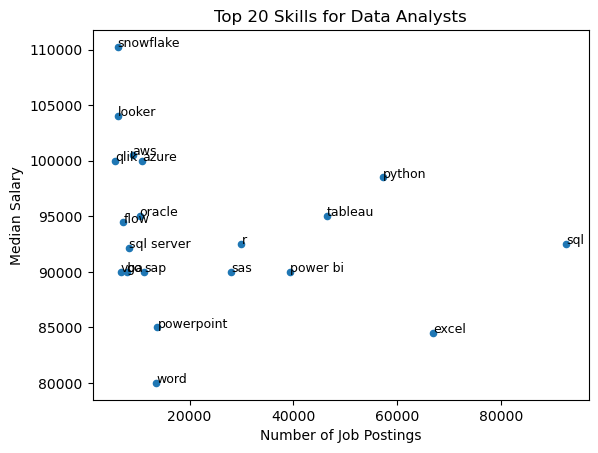

In [15]:
skills_stat_2= skills_stat.sort_values(by='count', ascending=False).head(20).copy()
skills_stat_2.plot(kind='scatter', x='count', y='median_pay')
plt.title("Top 20 Skills for Data Analysts")
plt.xlabel("Number of Job Postings")
plt.ylabel("Median Salary")

for skill in skills_stat_2.index:
    x = skills_stat_2.loc[skill, 'count']
    y = skills_stat_2.loc[skill, 'median_pay']
    plt.text(x, y, skill, fontsize=9)
plt.show()

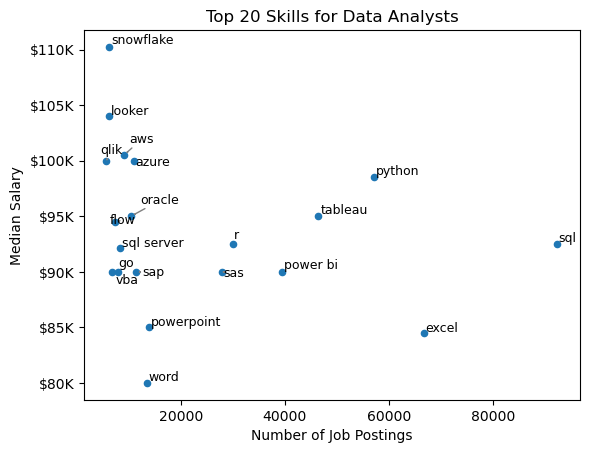

In [27]:
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter
skills_stat_3= skills_stat.sort_values(by='count', ascending=False).head(20).copy()
skills_stat_3.plot(kind='scatter', x='count', y='median_pay')
texts = [plt.text(row['count'], row['median_pay'], row.name, fontsize=9) for _, row in skills_stat_3.iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))
plt.title("Top 20 Skills for Data Analysts")
plt.xlabel("Number of Job Postings")
plt.ylabel("Median Salary")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'${y/1000:.0f}K')
)

plt.show()

In [20]:
skills_stat_3

,count,median_pay
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000
